# Spam classification

## Import Data

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 

##  Exploratory Data Analysis

In [3]:
type(X)

pandas.core.frame.DataFrame

In [4]:
type(y)

pandas.core.frame.DataFrame

In [5]:
import pandas as pd

In [6]:
data = pd.concat([X,y], axis=1)
data.head()  # Display the first 5 rows data

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [7]:
# Check for null values(missing information)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [8]:
data.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [9]:
# check for duplicate email 
duplicate_indices=data.duplicated()  # Return a boolean series(true or flase)
duplicate_indices

0       False
1       False
2       False
3       False
4       False
        ...  
4596    False
4597    False
4598    False
4599    False
4600    False
Length: 4601, dtype: bool

In [10]:
data.duplicated().any()

np.True_

In [11]:
duplicate_rows=data[duplicate_indices] # Return the duplicated rows value only
duplicate_rows

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
26,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.000,0.196,0.000,0.392,0.196,0.0,5.466,22,82,1
103,0.0,0.0,0.64,0.0,0.0,0.64,0.0,0.0,0.0,0.0,...,0.094,0.189,0.284,0.662,0.000,0.0,10.068,131,292,1
104,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.305,0.611,0.000,1.529,0.000,0.0,5.500,22,66,1
105,0.0,0.0,0.64,0.0,0.0,0.64,0.0,0.0,0.0,0.0,...,0.094,0.189,0.284,0.662,0.000,0.0,10.068,131,292,1
106,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.305,0.611,0.000,1.529,0.000,0.0,5.500,22,66,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4439,0.0,0.0,0.74,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.036,0.147,0.000,0.147,0.000,0.0,2.587,55,282,0
4441,0.0,0.0,0.74,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.036,0.147,0.000,0.147,0.000,0.0,2.587,55,282,0
4537,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.0,1.000,1,6,0
4541,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.0,1.000,1,2,0


In [12]:
len(data) - len(duplicate_rows)

4210

In [13]:
data = data.drop_duplicates()
len(data)

4210

As there's no categoric column and most numeric columns arein similar range , no preprocessing is requried.

## Train-test split

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
data['Class'].value_counts(normalize=True)

Class
0    0.601188
1    0.398812
Name: proportion, dtype: float64

In [19]:
target_column = 'Class'
features = data.drop(columns=target_column)  # Remove target column
target = data[target_column]  # 

In [20]:
X_train, X_test, y_train, y_test = train_test_split(features,
                                                    target,
                                                    test_size=0.2,  # 20% of email for testing
                                                    stratify=target # Maintain target distribution 
                                                   )

If the 'stratify= target' is not specified , there's a possibility that after splitting the data , there could be more data of **non-spam** and less data  of spam .So ,there 's little *spam* data for the model to learn  from.

In [22]:
y_train.value_counts(normalize=True)

Class
0    0.601247
1    0.398753
Name: proportion, dtype: float64

In [23]:
y_test.value_counts(normalize=True)

Class
0    0.60095
1    0.39905
Name: proportion, dtype: float64

## Model Training 

In [24]:
from sklearn .neighbors import KNeighborsClassifier

In [25]:
knn = KNeighborsClassifier()

In [26]:
knn.fit(X_train,y_train)  # Model training

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Model Evaluation

# Train Performance

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [28]:
y_train_pred = knn.predict(X_train)

In [29]:
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_train

0.8622327790973872

In [30]:
precision_train = precision_score(y_train, y_train_pred)
precision_train

0.839907192575406

In [37]:
recall_train = recall_score(y_train, y_train_pred)
recall_train

0.8086373790022338

# Test performance

In [34]:
y_test_pred = knn.predict(X_test)

In [35]:
accuracy_test = accuracy_score(y_test, y_test_pred)
accuracy_test

0.7874109263657957

In [36]:
precision_test = precision_score(y_test, y_test_pred)
precision_test

0.7386018237082067

In [38]:
recall_test = recall_score(y_test, y_test_pred)
recall_test

0.7232142857142857

In [ ]:
test_email = X_test.iloc[3:4]
test_email  

In [ ]:
y_test.iloc[3]

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator?

Signature:
ConfusionMatrixDisplay.from_estimator(
    estimator,
    X,
    y,
    *,
    labels=None,
    sample_weight=None,
    normalize=None,
    display_labels=None,
    include_values=True,
    xticks_rotation='horizontal',
    values_format=None,
    cmap='viridis',
    ax=None,
    colorbar=True,
    im_kw=None,
    text_kw=None,
)
Docstring:
Plot Confusion Matrix given an estimator and some data.

For general information regarding `scikit-learn` visualization tools, see
the :ref:`Visualization Guide <visualizations>`.
For guidance on interpreting these plots, refer to the
:ref:`Model Evaluation Guide <confusion_matrix>`.

.. versionadded:: 1.0

Parameters
----------
estimator : estimator instance
    Fitted classifier or a fitted :class:`~sklearn.pipeline.Pipeline`
    in which the last estimator is a classifier.

X : {array-like, sparse matrix} of shape (n_samples, n_features)
    Input values.

y : array-like of shape (n_samples,)
    Target values.

labels : array-like of 

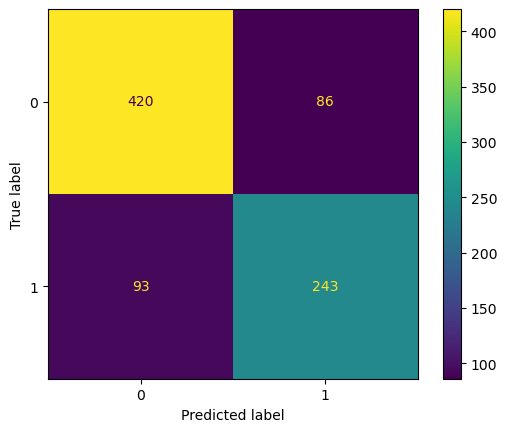

In [44]:
ConfusionMatrixDisplay.from_estimator(knn,
                                       X_test,
                                       y_test,
                                      )